# 1. 检查T细胞标签与表达

本次检查两位参考供者和五位已经查看过预测的供者，沿用作者标签，不删除细胞，也不重新拟合。先读取实际RCTD参考特征，再逐细胞检查原始计数。


In [1]:
from pathlib import Path
import runpy
import subprocess
import pandas as pd
from IPython.display import display, Image, Markdown
root = Path("/Users/georicl/Documents/sc_sncell_github")
result_dir = root / "results/Wu2021_tcell_label_review_v1"
subprocess.run(["Rscript", str(root / "src/sc_sncell_github/export_tcell_reference_profiles.R")], check=True)
runpy.run_path(str(root / "src/sc_sncell_github/review_tcell_labels.py"))


donor_id reference_label  n_cells  umi_median  genes_median  mito_median  T_marker_positive  CD8_positive  CD4_positive  no_T_or_CD8
 CID4471    T cells CD4+      412      2663.0        1024.5     6.934132                408            37            82            4
 CID4471    T cells CD8+      159      2169.0         979.0     7.329843                157           136             3            2
 CID4535    T cells CD4+      239       584.0         343.0     5.128205                105            18            15          132
 CID4535    T cells CD8+       98      2878.0        1095.5     3.718980                 93            59             0            4
 CID4067    T cells CD4+      353      1132.0         535.0     3.074558                309            19            11           40
 CID4067    T cells CD8+      243       983.0         520.0     3.274559                223           120             2           13
 CID4463    T cells CD4+      115      1264.0         628.0     2.979

{'__name__': '<run_path>',
 '__doc__': '检查作者T细胞标签、表达信息、参考状态覆盖和已拟合特征；不改标签。',
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': '/Users/georicl/Documents/sc_sncell_github/src/sc_sncell_github/review_tcell_labels.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.",
  '__package__': '',
  '__loader__': _frozen_importlib.BuiltinImporter,
  '__spec__': ModuleSpec(name='builtins', loader=<class '_frozen_importlib.BuiltinImporter'>, origin='built-in'),
  '__build_class__': <function __build_class__>,
  '__import_

# 2. 查看标志检测和参考状态

检测表示原始计数至少1。六个T标志任意一个检出，记为T标志检出；CD8A或CD8B任意一个检出，记为CD8检出。未检出不等于细胞类型错误。


,donor_id,reference_label,n_cells,umi_median,genes_median,mito_median,T_marker_positive,CD8_positive,CD4_positive,no_T_or_CD8
0,CID4471,T cells CD4+,412,2663.0,1024.5,6.934132,408,37,82,4
1,CID4471,T cells CD8+,159,2169.0,979.0,7.329843,157,136,3,2
5,CID4535,T cells CD4+,239,584.0,343.0,5.128205,105,18,15,132
6,CID4535,T cells CD8+,98,2878.0,1095.5,3.718980,93,59,0,4
10,CID4067,T cells CD4+,353,1132.0,535.0,3.074558,309,19,11,40
11,CID4067,T cells CD8+,243,983.0,520.0,3.274559,223,120,2,13
15,CID4463,T cells CD4+,115,1264.0,628.0,2.979738,111,14,14,4
16,CID4463,T cells CD8+,75,1078.0,560.0,3.157064,72,58,0,0
20,CID3941,T cells CD4+,108,2137.0,764.5,3.810956,101,11,3,6
21,CID3941,T cells CD8+,126,1641.0,718.5,4.338487,120,99,1,2


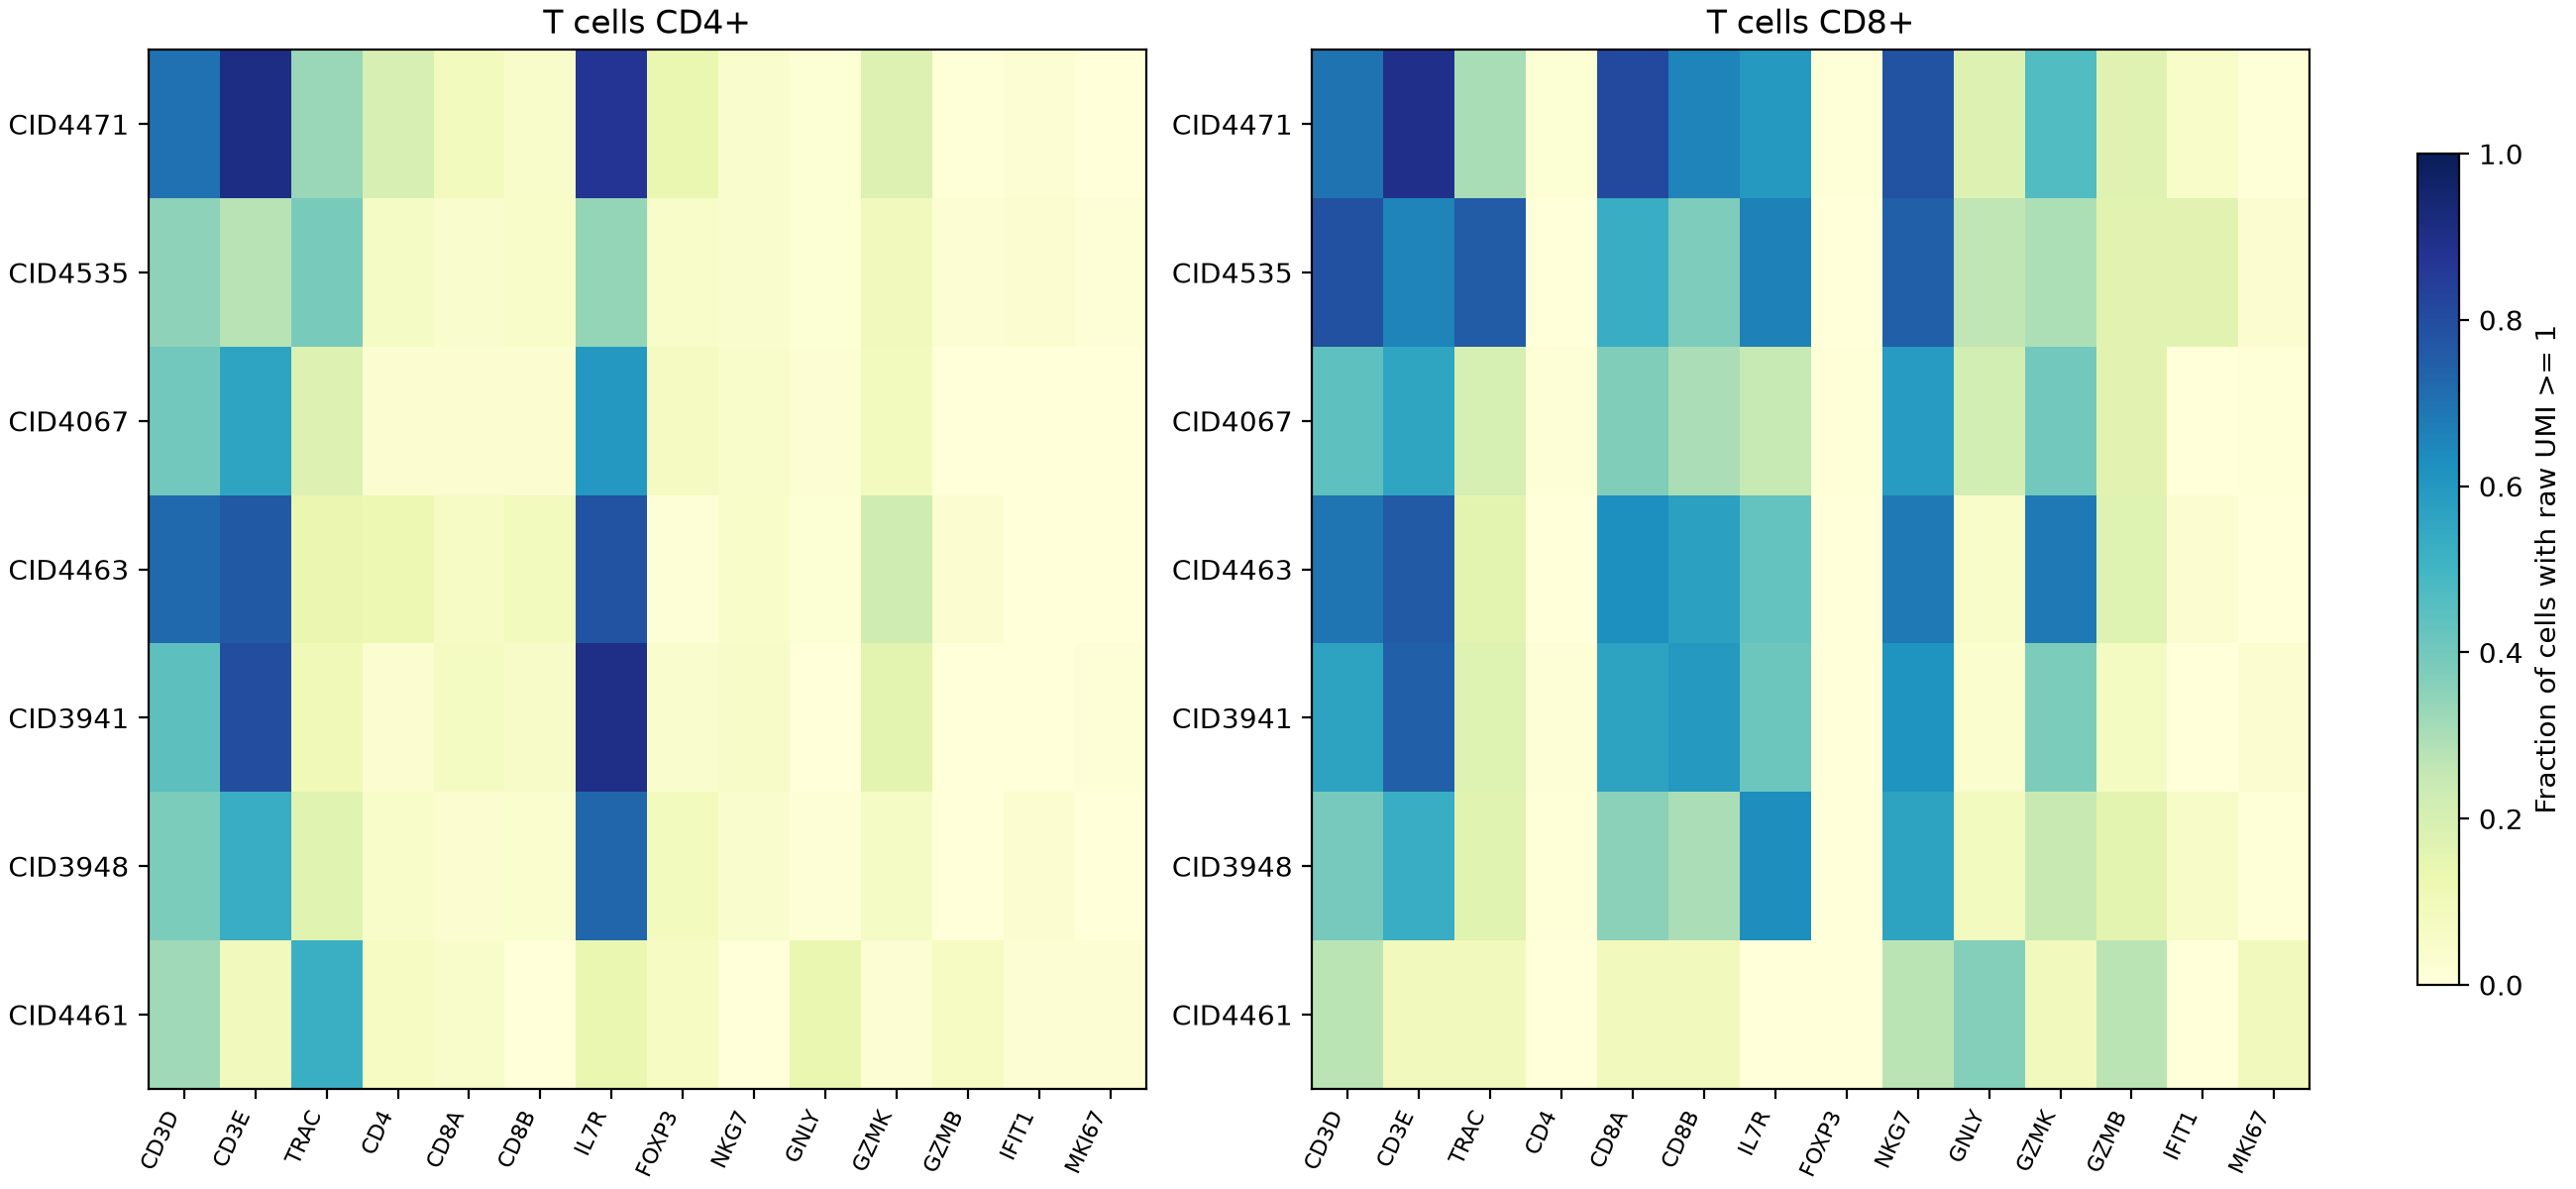

In [2]:
summary = pd.read_csv(result_dir / "label_marker_summary.csv")
display(summary[summary.reference_label.isin(["T cells CD4+", "T cells CD8+"])])
display(Image(filename=str(result_dir / "marker_detection_by_donor.png")))


# 3. 检查CID4461的11个CD8和CID4535的CD4

逐细胞查看作者状态、UMI和检测基因数，以及T细胞、CD8及其他谱系相关表达。多种类型共享的表达不能单独用于改标签。


,celltype_subset,nCount_RNA,nFeature_RNA,T_marker_umi,CD8A,CD8B,GNLY,KLRD1
barcode,,,,,,,,
CID4461_CCTACACTCTTCCTTC,T_cells_c4_CD8+_ZFP36,428,287,1,0,0,9,0
CID4461_CGTCAGGCAACTGGCC,T_cells_c4_CD8+_ZFP36,389,279,1,0,0,5,0
CID4461_GGGTCTGGTTCTGAAC,T_cells_c4_CD8+_ZFP36,274,212,3,0,0,0,1
CID4461_GCATACAAGGATGCGT,T_cells_c4_CD8+_ZFP36,261,208,2,0,0,0,0
CID4461_TCACAAGTCCGAGCCA,T_cells_c4_CD8+_ZFP36,324,239,1,0,0,6,1
CID4461_GTGAAGGTCATCACCC,T_cells_c6_IFIT1,423,309,0,0,0,0,0
CID4461_AGCCTAACAGGTTTCA,T_cells_c7_CD8+_IFNG,275,221,0,1,0,1,0
CID4461_ATTTCTGCACCATCCT,T_cells_c7_CD8+_IFNG,755,497,2,0,0,0,2
CID4461_CGCTGGATCTACCAGA,T_cells_c7_CD8+_IFNG,400,298,2,0,0,0,0


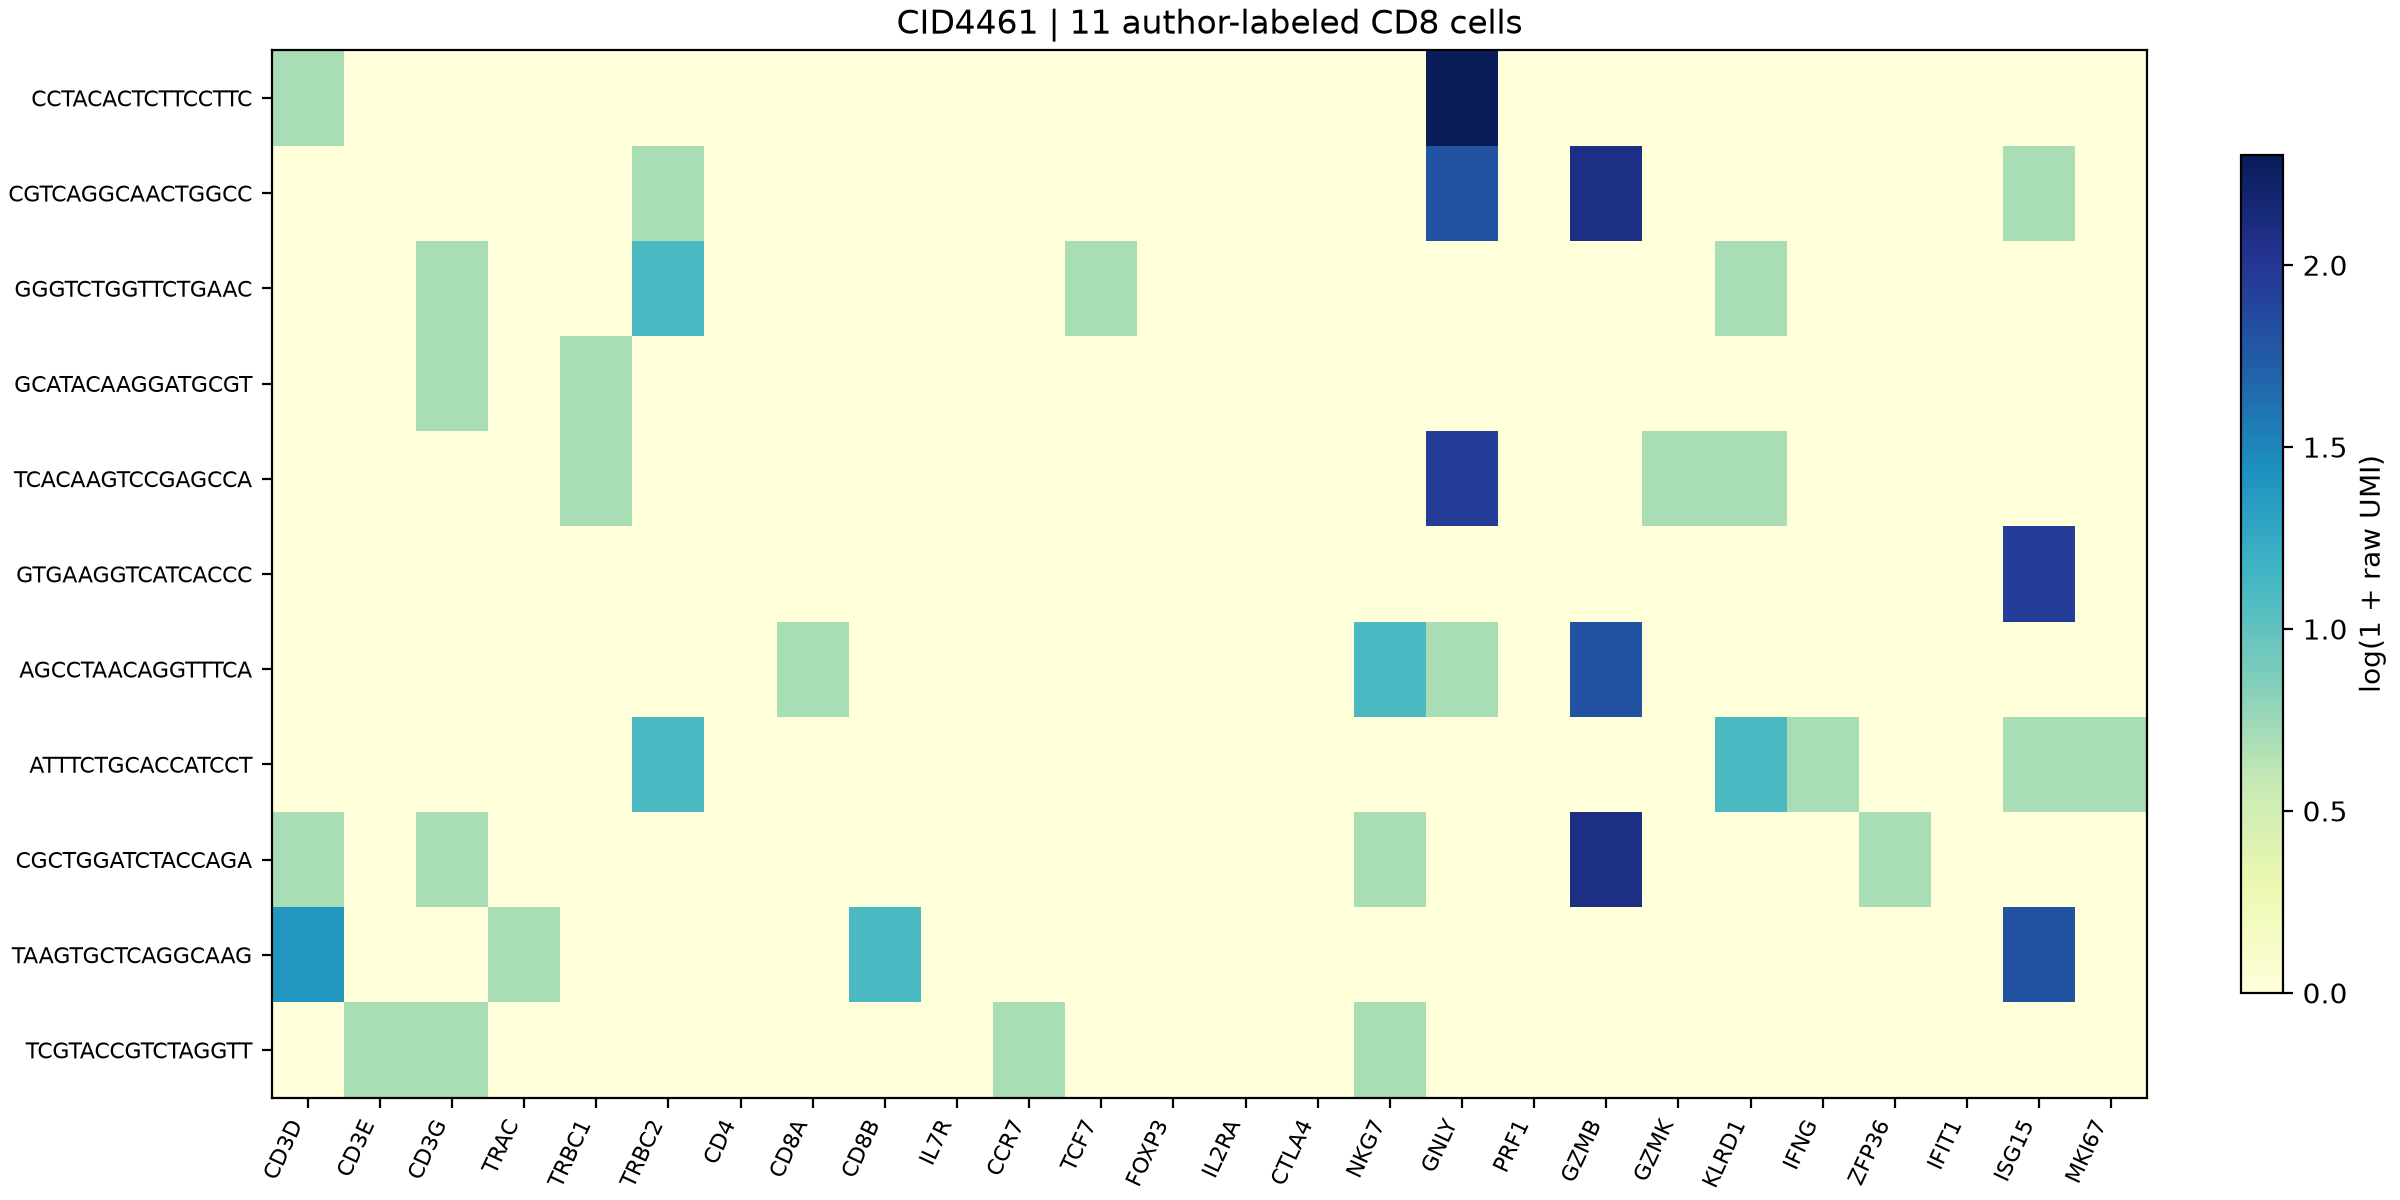

,n_cells,umi_median,T_marker_positive,CD8_positive
celltype_subset,,,,
T_cells_c0_CD4+_CCR7,23,3438.0,23,5
T_cells_c1_CD4+_IL7R,166,377.0,34,12
T_cells_c2_CD4+_T-regs_FOXP3,31,2594.0,29,1
T_cells_c3_CD4+_Tfh_CXCL13,19,3245.0,19,0


,variant,reference_label,n_cells,CID4535_cells,no_T_or_CD8,no_T_or_CD8_fraction
0,baseline,Cycling T-cells,27,19,15,0.555556
1,baseline,NK cells,55,25,10,0.181818
2,baseline,NKT cells,47,15,4,0.085106
3,baseline,T cells CD4+,651,239,136,0.208909
4,baseline,T cells CD8+,257,98,6,0.023346
5,donor_balanced,Cycling T-cells,27,19,15,0.555556
6,donor_balanced,NK cells,50,25,9,0.180000
7,donor_balanced,NKT cells,30,15,4,0.133333
8,donor_balanced,T cells CD4+,478,239,135,0.282427
9,donor_balanced,T cells CD8+,196,98,5,0.025510


In [3]:
focus = pd.read_csv(result_dir / "CID4461_11_CD8_review.csv", index_col=0)
display(focus[["celltype_subset", "nCount_RNA", "nFeature_RNA", "T_marker_umi", "CD8A", "CD8B", "GNLY", "KLRD1"]])
display(Image(filename=str(result_dir / "CID4461_marker_counts.png")))
cd4 = pd.read_csv(result_dir / "CID4535_CD4_review.csv", index_col=0)
display(cd4.groupby("celltype_subset").agg(n_cells=("reference_label", "size"), umi_median=("nCount_RNA", "median"), T_marker_positive=("T_markers_detected", "sum"), CD8_positive=("CD8_detected", "sum")))
display(pd.read_csv(result_dir / "reference_marker_coverage_by_variant.csv"))


# 4. 核对实际模型特征与配方来源

读取已拟合模型的参考表达和筛选基因，核对查看的基因是否进入模型。配方预测关联到来源细胞，仅表示细胞参与了相应配方，不是该细胞单独的预测。


In [4]:
features = pd.read_csv(result_dir / "marker_feature_coverage.csv")
display(features[features.validation_donor.eq("CID3941") & features.gene.isin(["CD4", "CD8A", "CD8B", "FOXP3", "IL7R"])])
mixtures = pd.read_csv(result_dir / "zero_CD8_mixture_source_review.csv")
display(mixtures[mixtures.variant.eq("baseline")])


,variant,validation_donor,gene,in_RCTD,in_NNLS,reference_CD4_profile,reference_CD8_profile
6,baseline,CID3941,CD4,False,True,0.000072,0.000007
7,baseline,CID3941,CD8A,True,True,0.000051,0.000972
8,baseline,CID3941,CD8B,True,True,0.000036,0.000527
9,baseline,CID3941,IL7R,True,True,0.001678,0.001289
12,baseline,CID3941,FOXP3,False,False,0.000067,0.000001
123,donor_balanced,CID3941,CD4,False,True,0.000070,0.000004
124,donor_balanced,CID3941,CD8A,True,True,0.000047,0.000892
125,donor_balanced,CID3941,CD8B,True,True,0.000038,0.000493
126,donor_balanced,CID3941,IL7R,True,True,0.001426,0.001137
129,donor_balanced,CID3941,FOXP3,False,False,0.000060,0.000000


,donor_id,variant,spot_id,predicted_CD8_pct,source_CD4_detected,source_CD8_detected,source_T_detected,source_states
0,CID3941,baseline,CID3941_mix000_depth100,0.031786,0,0,10,"{""T_cells_c1_CD4+_IL7R"": 5, ""T_cells_c2_CD4+_T..."
1,CID3941,baseline,CID3941_mix003_depth100,5.870023,1,0,10,"{""T_cells_c1_CD4+_IL7R"": 5, ""T_cells_c0_CD4+_C..."
2,CID3941,baseline,CID3941_mix006_depth100,31.073848,0,1,10,"{""T_cells_c1_CD4+_IL7R"": 8, ""T_cells_c0_CD4+_C..."
3,CID3941,baseline,CID3941_mix009_depth100,0.027569,0,0,10,"{""T_cells_c0_CD4+_CCR7"": 4, ""T_cells_c1_CD4+_I..."
4,CID3941,baseline,CID3941_mix012_depth100,0.021062,2,0,10,"{""T_cells_c1_CD4+_IL7R"": 5, ""T_cells_c0_CD4+_C..."
20,CID3948,baseline,CID3948_mix000_depth100,24.156786,0,0,9,"{""T_cells_c2_CD4+_T-regs_FOXP3"": 5, ""T_cells_c..."
21,CID3948,baseline,CID3948_mix003_depth100,52.106721,1,1,9,"{""T_cells_c1_CD4+_IL7R"": 6, ""T_cells_c2_CD4+_T..."
22,CID3948,baseline,CID3948_mix006_depth100,37.920048,0,2,8,"{""T_cells_c1_CD4+_IL7R"": 5, ""T_cells_c2_CD4+_T..."
23,CID3948,baseline,CID3948_mix009_depth100,46.544627,0,1,8,"{""T_cells_c1_CD4+_IL7R"": 6, ""T_cells_c2_CD4+_T..."
24,CID3948,baseline,CID3948_mix012_depth100,0.028022,0,0,8,"{""T_cells_c3_CD4+_Tfh_CXCL13"": 4, ""T_cells_c2_..."


# 5. 复核与解读


In [5]:
runpy.run_path(str(root / "src/sc_sncell_github/validate_tcell_label_review.py"))
display(Markdown((result_dir / "interpretation.md").read_text()))


Checks: 59 / 59


# T细胞标签与参考表达核对

## 1. 本次检查

检查7位供者的3742个作者标注CD4、CD8、NK、NKT及Cycling T细胞。读取原始UMI，逐细胞保存39个查看基因；没有删除细胞、修改标签或重新拟合。
T标志检测指CD3D、CD3E、CD3G、TRAC、TRBC1、TRBC2中任一个原始计数至少1；CD8检测指CD8A或CD8B至少1。未检出只描述这份RNA数据，不等于证明细胞不属于该类型。

## 2. CID4461的11个CD8

UMI中位数400，检测基因中位数287。9/11检出至少一个本次定义的T标志，只有2/11检出CD8A或CD8B，0/11检出CD4。
作者状态为5个CD8+ ZFP36、5个CD8+ IFNG及1个IFIT1。参考侧也有这些状态，不能说它们在参考中完全缺失；但这11个细胞提供的CD8直接表达信息很少。
其中部分细胞检出GNLY或KLRD1，不能仅凭这些共享表达把作者CD8标签改为NK或NKT。应保留原标签，同时记录为低信息验证组。

## 3. CID4535的CD4参考需要重点复核

CID4471的412个CD4中，408个检出T标志；CID4535的239个CD4中只有105个。CID4535有132个同时未检出上述T标志及CD8标志，CID4471对应为4个。
问题集中在CID4535的CD4+ IL7R状态：166个细胞，UMI中位数377，只有34个检出T标志。其余CD4状态UMI中位数为2594至3438。
CID4535的CD4中，145个检出KRT19，63个在EPCAM、KRT8、KRT18、KRT19中检出至少两个；33个同时没有检出上述T/CD8标志。这需要区分环境RNA、低信息细胞和标签混杂，当前证据不足以直接改成上皮标签。
供者均衡把CID4535在CD4参考中的占比从239/651（36.7%）提高到239/478（50.0%）；无T/CD8标志的细胞比例从136/651（20.9%）提高到135/478（28.2%）。均衡确实增加了这部分低信息参考的占比，是否导致预测恶化还需单独对照。

## 4. 实际模型特征

本轮12次RCTD拟合均保留CD8A、CD8B，但没有保留CD4和FOXP3。原参考CD4基因在全部类型中的最高平均相对表达约0.000163，低于当前回归基因阈值0.0002；FOXP3最高约0.0000666，也低于阈值。安装版本getDeGenes要求类型表达超过此阈值，因此这两者未能进入回归特征。
这符合当前筛选规则，不是代码报错。降低阈值或定向保留标志可以作为后续对照，但本次未修改参数，也没有证明只加入CD4就能解决混淆。NNLS保留了CD4，仍然存在误差。
按两位参考的合并CD8/CD4表达差异挑选前100个基因，其中81个在两位供者的方向一致。该统计为描述性比值，不是显著性检验。部分偏向CD4的差异主要由CID4535贡献，例如KRT19、AGR2、SLC39A6，不能直接当作稳定的CD4区分特征。
实际筛选基因上的CD4/CD8参考余弦相似度较高，但相似度受共享表达影响，不能单独证明类型不可区分。完整数值保存在reference_profile_cosines.csv。

## 5. 零CD8配方里的来源CD4

CID3941误分配最高的原参考配方预测CD8为31.07%，来源为8个作者标注CD4+ IL7R及2个CD4+ CCR7。CID3948最高配方为52.11%，来源为6个CD4+ IL7R、2个Treg和2个CD4+ CCR7。两组都没有混入作者标注CD8。
这些配方分别只有1个来源细胞检出CD8A或CD8B。来源组成支持检查CD4状态与参考表达之间的差异，但spot级误差不能归责为某一个来源细胞预测错误。
CD4_cells_in_zero_CD8_mixtures.csv列出全部来源细胞与其出现配方的平均预测；该列是关联配方的预测，不是单细胞预测。

## 6. 当前修订方向

优先复核CID4535的CD4+ IL7R参考，设计保留全量与仅使用表达支持较充分细胞的对照，避免直接按预测好坏删细胞。CID4461的11个CD8继续保留，单列为低信息组。
另做基因特征对照，检查CD4等标志保留前后的影响，并同时查看CD4→CD8误分配和真实CD8的检出。两项调整应分别进行，才能判断各自作用。
原标签来源为本地Wu作者metadata；原研究：[Wu et al., 2021](https://pubmed.ncbi.nlm.nih.gov/34493872/)。本次基因查看和表达对照不能代替蛋白或TCR证据。
